# 🏥 Permission to Live
## A Data Investigation into Women's Healthcare Inequality Across Bangladesh

**Data Source:** Bangladesh Demographic and Health Survey (BDHS) 2022  
**Sample Size:** 30,078 women across 8 divisions  
**Tools:** Python, pandas, seaborn, matplotlib, folium ,Power BI 

**By:** Aniqua Nawar | University of Liberal Arts Bangladesh  

---

### What this project investigates:
In Bangladesh, a woman's health is not just determined by disease.  
It is determined by **where she was born**, **how educated she is**,  
and whether **someone will give her permission to see a doctor.**

### Key Questions:
- Which divisions leave women most vulnerable?
- Does wealth protect women from healthcare barriers?
- Is the barrier physical (distance) or social (permission)?
  

In [1]:
# Step 1: Import the libraries we need
# A library is a collection of tools someone else built that we can use for free

import pandas as pd        # pandas = our main tool for working with data
import numpy as np         # numpy = helps with numbers and calculations
import matplotlib.pyplot as plt  # matplotlib = for making charts
import seaborn as sns      # seaborn = makes beautiful statistical charts

print("All libraries loaded successfully!")

All libraries loaded successfully!


In [2]:
# Step 2: Install pyreadstat
# This library lets Python read .DTA files (Stata format) from DHS
# We only need to run this ONCE ever

import subprocess
subprocess.run(["pip", "install", "pyreadstat"])

CompletedProcess(args=['pip', 'install', 'pyreadstat'], returncode=0)

In [4]:
# Step 3: Load the women's individual data (IR file)
# This is the most important dataset — contains data on 20,000+ Bangladeshi women
# pd.read_stata() is the command that reads .DTA (Stata) files into Python
# We are saving it into a variable called 'women_df'
# 'df' stands for DataFrame — think of it as a table with rows and columns

women_df = pd.read_stata(
    r"C:\Users\User\OneDrive\Desktop\Project1_BD_Health_Atlas\BDIR81DT\BDIR81FL.DTA"
)

print("Data loaded!")
print("Number of rows:", len(women_df))
print("Number of columns:", len(women_df.columns))

Data loaded!
Number of rows: 30078
Number of columns: 5425


In [5]:
# Step 4: Look at the first 5 rows of our data
# .head() shows the first 5 rows by default
# This is always the FIRST thing you do with any new dataset
# It's like opening a book to the first page to understand what's inside

women_df.head()

,caseid,v000,v001,v002,v003,v004,v005,v006,v007,v008,...,s631j_3,s631j_4,s631j_5,s631j_6,s631k_1,s631k_2,s631k_3,s631k_4,s631k_5,s631k_6
0,1 1 3,BD8,1,1,3,1,156207,9,2022,1473,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1 4 2,BD8,1,4,2,1,156207,9,2022,1473,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1 7 3,BD8,1,7,3,1,156207,9,2022,1473,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1 10 2,BD8,1,10,2,1,156207,9,2022,1473,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1 13 2,BD8,1,13,2,1,156207,9,2022,1473,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
# Step 5: Find our key columns
# Out of 5425 columns we only need about 10-15 for our project
# These are the most important DHS standard column codes for women's health
# I'm selecting them by name and creating a smaller, cleaner table

key_columns = [
    'v001',   # Cluster number
    'v002',   # Household number  
    'v005',   # Sample weight (important for accurate statistics)
    'v007',   # Year of interview
    'v013',   # Age group
    'v025',   # Urban or Rural
    'v024',   # Region/Division (this is our map column!)
    'v106',   # Education level
    'v190',   # Wealth index (rich/poor)
    'v151',   # Sex of household head
    'v212',   # Age at first birth
    'v301',   # Knowledge of contraception
    'v384a',  # Heard family planning on radio
    's116',   # Has health insurance
    'v461',   # Currently pregnant
]

# Now let's check which of these actually exist in our dataset
existing_columns = [col for col in key_columns if col in women_df.columns]
missing_columns = [col for col in key_columns if col not in women_df.columns]

print("Columns found:", existing_columns)
print("\nColumns NOT found:", missing_columns)

Columns found: ['v001', 'v002', 'v005', 'v007', 'v013', 'v025', 'v024', 'v106', 'v190', 'v151', 'v212', 'v301', 'v384a', 'v461']

Columns NOT found: ['s116']


In [7]:
# Step 6: Create a clean DataFrame with only our key columns
# We use only the columns that actually exist (existing_columns)
# This makes our data much easier to work with
# Think of it like hiding irrelevant columns in Excel

women_clean = women_df[existing_columns].copy()
# .copy() means we create a brand new independent table
# without .copy(), changes to women_clean could affect women_df

print("Clean DataFrame created!")
print("Shape:", women_clean.shape)
# .shape tells us (number of rows, number of columns)

print("\nColumn names and their meaning:")
column_meanings = {
    'v001': 'Cluster Number',
    'v002': 'Household Number',
    'v005': 'Sample Weight',
    'v007': 'Year of Interview',
    'v013': 'Age Group',
    'v025': 'Urban or Rural',
    'v024': 'Division/Region',
    'v106': 'Education Level',
    'v190': 'Wealth Index',
    'v151': 'Sex of Household Head',
    'v212': 'Age at First Birth',
    'v301': 'Knowledge of Contraception',
    'v384a': 'Heard Family Planning on Radio',
    'v461': 'Currently Pregnant'
}

for code, meaning in column_meanings.items():
    print(f"  {code} → {meaning}")

Clean DataFrame created!
Shape: (30078, 14)

Column names and their meaning:
  v001 → Cluster Number
  v002 → Household Number
  v005 → Sample Weight
  v007 → Year of Interview
  v013 → Age Group
  v025 → Urban or Rural
  v024 → Division/Region
  v106 → Education Level
  v190 → Wealth Index
  v151 → Sex of Household Head
  v212 → Age at First Birth
  v301 → Knowledge of Contraception
  v384a → Heard Family Planning on Radio
  v461 → Currently Pregnant


In [8]:
# Step 7: Explore each column — understand what values exist
# .value_counts() counts how many times each unique value appears
# This tells us what's actually IN our data

print("=" * 50)
print("DIVISION/REGION (v024) — our map column")
print("=" * 50)
print(women_clean['v024'].value_counts())

print("\n" + "=" * 50)
print("URBAN or RURAL (v025)")
print("=" * 50)
print(women_clean['v025'].value_counts())

print("\n" + "=" * 50)
print("EDUCATION LEVEL (v106)")
print("=" * 50)
print(women_clean['v106'].value_counts())

print("\n" + "=" * 50)
print("WEALTH INDEX (v190)")
print("=" * 50)
print(women_clean['v190'].value_counts())

DIVISION/REGION (v024) — our map column
v024
dhaka         4554
chattogram    4461
khulna        3928
rajshahi      3816
rangpur       3624
mymensingh    3255
barishal      3232
sylhet        3208
Name: count, dtype: int64

URBAN or RURAL (v025)
v025
rural    19507
urban    10571
Name: count, dtype: int64

EDUCATION LEVEL (v106)
v106
secondary       13613
primary          7857
higher           4441
no education     4167
Name: count, dtype: int64

WEALTH INDEX (v190)
v190
richest    6570
richer     6168
middle     5926
poorer     5855
poorest    5559
Name: count, dtype: int64


In [9]:
# Step 8: Analyze education level BY division
# This is our first real cross-analysis — two columns talking to each other
# pd.crosstab() creates a table that counts combinations of two columns
# normalize='index' converts raw counts to percentages per row
# so each division's numbers add up to 100%

edu_by_division = pd.crosstab(
    women_clean['v024'],  # rows = divisions
    women_clean['v106'],  # columns = education levels
    normalize='index'     # convert to percentages
) * 100  # multiply by 100 to show as % not decimal

# Round to 1 decimal place for readability
edu_by_division = edu_by_division.round(1)

print("Education Level by Division (% of women in each division)")
print("=" * 65)
print(edu_by_division)
print("\nKey question: Which division has the MOST women with no education?")
print("No education % by division:")
print(edu_by_division['no education'].sort_values(ascending=False))

Education Level by Division (% of women in each division)
v106        no education  primary  secondary  higher
v024                                                
barishal             8.0     27.8       45.8    18.4
chattogram          14.0     24.5       50.0    11.6
dhaka               12.9     26.1       44.4    16.6
khulna              10.2     22.6       51.2    15.9
mymensingh          18.1     29.1       39.3    13.5
rajshahi            13.8     24.1       45.8    16.4
rangpur             16.6     24.4       44.3    14.7
sylhet              18.1     32.5       38.6    10.8

Key question: Which division has the MOST women with no education?
No education % by division:
v024
sylhet        18.1
mymensingh    18.1
rangpur       16.6
chattogram    14.0
rajshahi      13.8
dhaka         12.9
khulna        10.2
barishal       8.0
Name: no education, dtype: float64


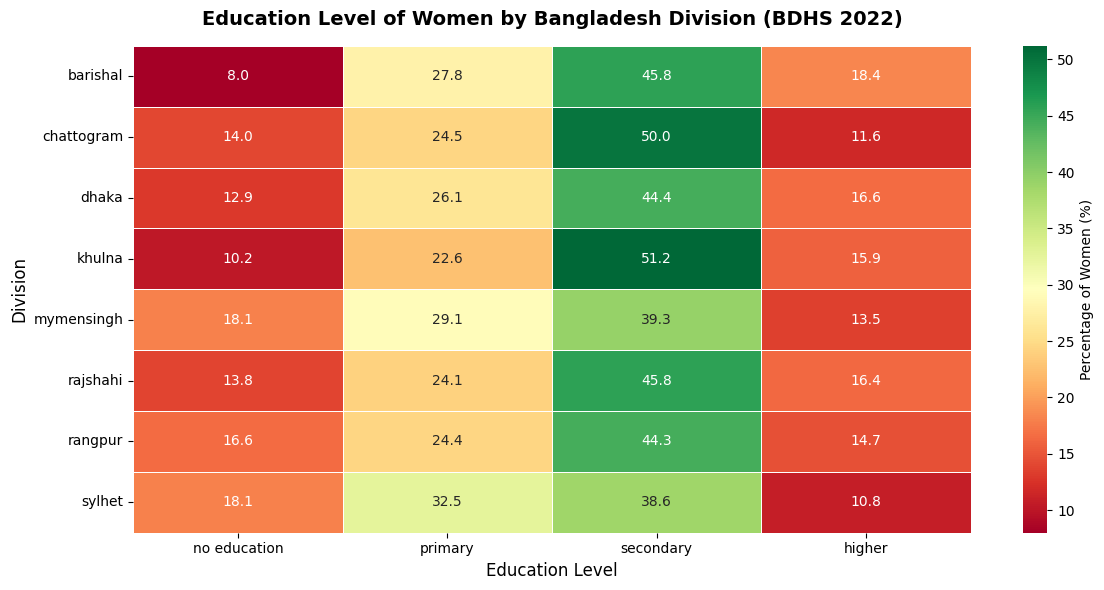

Chart saved as education_by_division.png


In [10]:
# Step 9: Visualize education by division — our first chart!
# We use seaborn's heatmap — it shows a table as colors
# Dark color = high percentage, Light color = low percentage
# This makes patterns VISIBLE that are hard to see in numbers

plt.figure(figsize=(12, 6))
# figsize=(width, height) in inches — controls how big the chart is

sns.heatmap(
    edu_by_division,           # our data table
    annot=True,                # annot=True means show the numbers inside each box
    fmt='.1f',                 # format numbers to 1 decimal place
    cmap='RdYlGn',            # color map: Red=bad, Yellow=middle, Green=good
    linewidths=0.5,            # thin lines between boxes
    cbar_kws={'label': 'Percentage of Women (%)'}  # label for color bar
)

plt.title(
    'Education Level of Women by Bangladesh Division (BDHS 2022)',
    fontsize=14,
    fontweight='bold',
    pad=15
)
plt.xlabel('Education Level', fontsize=12)
plt.ylabel('Division', fontsize=12)
plt.xticks(rotation=0)   # keep x labels horizontal
plt.yticks(rotation=0)   # keep y labels horizontal
plt.tight_layout()       # prevents labels from getting cut off
plt.savefig('education_by_division.png', dpi=150, bbox_inches='tight')
# saves the chart as an image file in your project folder
plt.show()

print("Chart saved as education_by_division.png")

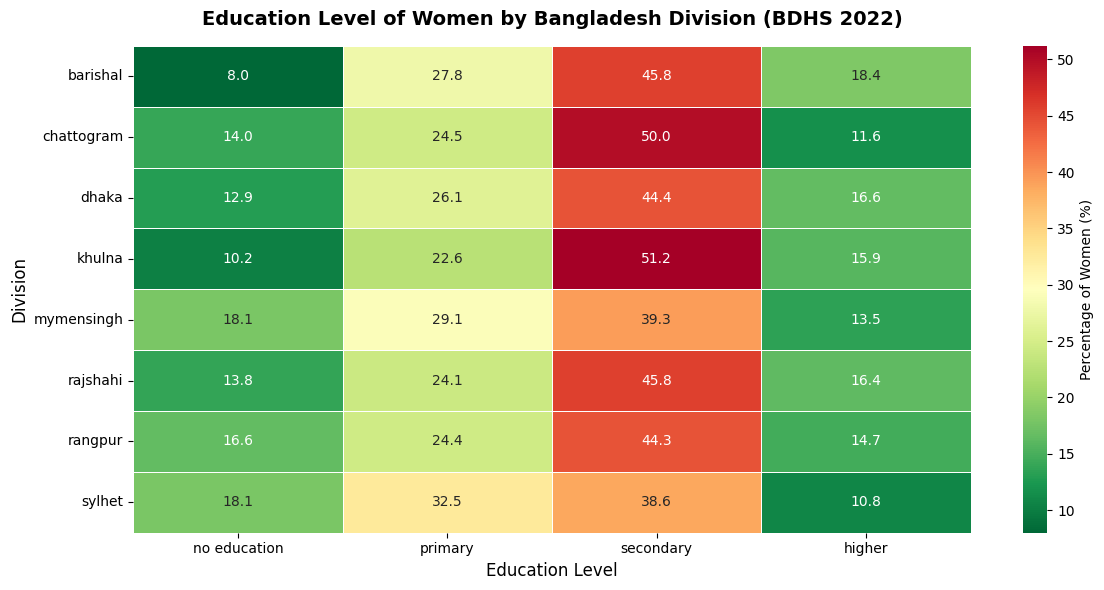

Fixed chart saved!


In [11]:
# Fixing the colormap to be more intuitive
# For "no education" column, HIGH percentage = BAD
# So we want: Green = low (good), Red = high (bad)
# We use 'RdYlGn_r' — the _r means REVERSED

plt.figure(figsize=(12, 6))

sns.heatmap(
    edu_by_division,
    annot=True,
    fmt='.1f',
    cmap='RdYlGn_r',      # _r reverses it: now Red=high, Green=low
    linewidths=0.5,
    cbar_kws={'label': 'Percentage of Women (%)'}
)

plt.title(
    'Education Level of Women by Bangladesh Division (BDHS 2022)',
    fontsize=14,
    fontweight='bold',
    pad=15
)
plt.xlabel('Education Level', fontsize=12)
plt.ylabel('Division', fontsize=12)
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('education_by_division_v2.png', dpi=150, bbox_inches='tight')
plt.show()

print("Fixed chart saved!")

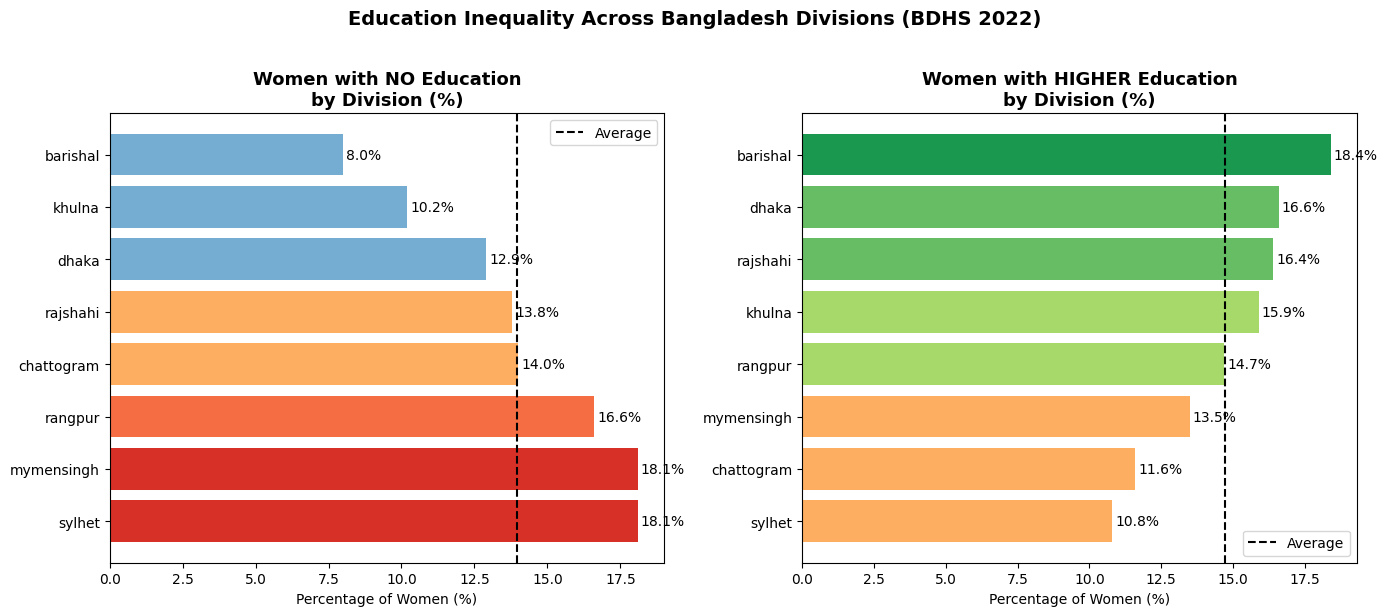

Chart saved!


In [12]:
# Step 10: Clear focused bar charts — one insight per chart
# We make 2 separate charts side by side
# Left: % with NO education by division (lower = better, red theme)
# Right: % with HIGHER education by division (higher = better, green theme)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
# fig = the whole figure
# axes = the two separate chart areas
# 1, 2 = 1 row, 2 columns of charts

# --- Chart 1: No Education ---
no_edu = edu_by_division['no education'].sort_values(ascending=False)
# sort_values(ascending=False) = highest % at top

colors_red = ['#d73027' if v == no_edu.max() 
              else '#f46d43' if v >= 16 
              else '#fdae61' if v >= 13 
              else '#74add1' 
              for v in no_edu.values]
# This gives each bar a color based on how bad it is
# Dark red = worst, blue = best

axes[0].barh(no_edu.index, no_edu.values, color=colors_red)
# barh = horizontal bar chart
# no_edu.index = division names (y axis)
# no_edu.values = percentages (x axis)

axes[0].set_title('Women with NO Education\nby Division (%)', 
                   fontsize=13, fontweight='bold')
axes[0].set_xlabel('Percentage of Women (%)')
axes[0].axvline(x=no_edu.mean(), color='black', 
                linestyle='--', linewidth=1.5, label='Average')
# axvline draws a vertical line at the average
axes[0].legend()

# Add % labels on each bar
for i, v in enumerate(no_edu.values):
    axes[0].text(v + 0.1, i, f'{v}%', va='center', fontsize=10)

# --- Chart 2: Higher Education ---
higher_edu = edu_by_division['higher'].sort_values(ascending=True)

colors_green = ['#1a9850' if v == higher_edu.max() 
                else '#66bd63' if v >= 16 
                else '#a6d96a' if v >= 14 
                else '#fdae61' 
                for v in higher_edu.values]

axes[1].barh(higher_edu.index, higher_edu.values, color=colors_green)
axes[1].set_title('Women with HIGHER Education\nby Division (%)', 
                   fontsize=13, fontweight='bold')
axes[1].set_xlabel('Percentage of Women (%)')
axes[1].axvline(x=higher_edu.mean(), color='black', 
                linestyle='--', linewidth=1.5, label='Average')
axes[1].legend()

for i, v in enumerate(higher_edu.values):
    axes[1].text(v + 0.1, i, f'{v}%', va='center', fontsize=10)

plt.suptitle('Education Inequality Across Bangladesh Divisions (BDHS 2022)', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('education_inequality.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved!")

In [13]:
# Saving our clean dataset so we don't have to reload everything next time
# to_csv saves our DataFrame as a CSV file
# index=False means don't save the row numbers as a column

women_clean.to_csv('women_clean.csv', index=False)
print("Clean dataset saved as women_clean.csv ✓")
print("Charts saved ✓")
print("Notebook saved ✓")

print("\n--- PROGRESS SUMMARY ---")
print("Dataset: BDHS 2022 Bangladesh")
print("Women surveyed:", len(women_clean))
print("Divisions covered:", women_clean['v024'].nunique())
print("Key finding 1: Sylhet & Mymensingh have highest female no-education rate (18.1%)")
print("Key finding 2: Barishal leads in higher education (18.4%)")
print("Key finding 3: 65% of surveyed women are rural")
print("Next step: Analyze healthcare access by division and wealth")

Clean dataset saved as women_clean.csv ✓
Charts saved ✓
Notebook saved ✓

--- PROGRESS SUMMARY ---
Dataset: BDHS 2022 Bangladesh
Women surveyed: 30078
Divisions covered: 8
Key finding 1: Sylhet & Mymensingh have highest female no-education rate (18.1%)
Key finding 2: Barishal leads in higher education (18.4%)
Key finding 3: 65% of surveyed women are rural
Next step: Analyze healthcare access by division and wealth


In [14]:
# Step 11: Find healthcare access columns
# In DHS data, antenatal care and birth delivery location
# tell us how much access women have to healthcare
# Let's find these specific columns

healthcare_columns = [
    'v151',   # Sex of household head
    'v157',   # Reads newspaper
    'v158',   # Listens to radio  
    'v159',   # Watches television
    'v393',   # Visited health facility last 12 months
    'v394',   # Visited health facility - how many times
    'v461',   # Currently pregnant
    'v467b',  # Distance to health facility - big problem
    'v467d',  # Getting permission to go - big problem
    'v467f',  # Not wanting to go alone - big problem
    'm14',    # Number of antenatal visits
    'm15',    # Place of delivery
    'm17',    # C-section delivery
]

existing_hc = [col for col in healthcare_columns if col in women_df.columns]
missing_hc = [col for col in healthcare_columns if col not in women_df.columns]

print("Healthcare columns found:", existing_hc)
print("\nNot found:", missing_hc)

Healthcare columns found: ['v151', 'v157', 'v158', 'v159', 'v393', 'v394', 'v461', 'v467b', 'v467d', 'v467f']

Not found: ['m14', 'm15', 'm17']


In [15]:
# Step 12: Add healthcare columns to our clean dataframe
# We already have women_clean with 14 columns
# Now we add the healthcare access columns to it

healthcare_cols_to_add = ['v157', 'v158', 'v159', 
                           'v393', 'v467b', 'v467d', 'v467f']

# Add these columns from the original women_df into women_clean
for col in healthcare_cols_to_add:
    women_clean[col] = women_df[col]

print("Healthcare columns added!")
print("New shape:", women_clean.shape)

print("\n" + "="*50)
print("VISITED HEALTH FACILITY last 12 months (v393)")
print("="*50)
print(women_clean['v393'].value_counts())

print("\n" + "="*50)
print("DISTANCE TO FACILITY is a big problem (v467b)")
print("="*50)
print(women_clean['v467b'].value_counts())

print("\n" + "="*50)
print("GETTING PERMISSION is a big problem (v467d)")
print("="*50)
print(women_clean['v467d'].value_counts())

print("\n" + "="*50)
print("NOT WANTING TO GO ALONE is a big problem (v467f)")
print("="*50)
print(women_clean['v467f'].value_counts())

Healthcare columns added!
New shape: (30078, 21)

VISITED HEALTH FACILITY last 12 months (v393)
Series([], Name: count, dtype: int64)

DISTANCE TO FACILITY is a big problem (v467b)
v467b
not a big problem    14900
big problem           5087
Name: count, dtype: int64

GETTING PERMISSION is a big problem (v467d)
v467d
not a big problem    10913
big problem           9074
Name: count, dtype: int64

NOT WANTING TO GO ALONE is a big problem (v467f)
v467f
not a big problem    12130
big problem           7857
Name: count, dtype: int64


In [16]:
# Step 13: Healthcare barriers by division
# We want to know: in which division do women face 
# the most barriers to accessing healthcare?
# We'll calculate % of women saying "big problem" 
# for each barrier in each division

# First let's create a summary table
barriers = {
    'Distance': 'v467b',
    'Permission': 'v467d', 
    'Going Alone': 'v467f'
}

# Create empty dataframe to store results
barrier_by_division = pd.DataFrame()

for barrier_name, col in barriers.items():
    # For each division, calculate % who said "big problem"
    pct = women_clean.groupby('v024')[col].apply(
        lambda x: (x == 'big problem').sum() / len(x) * 100
    ).round(1)
    barrier_by_division[barrier_name] = pct

print("Healthcare Barriers by Division (% saying 'big problem')")
print("="*55)
print(barrier_by_division)
print("\nWhich division has worst OVERALL barriers?")
barrier_by_division['Overall'] = barrier_by_division.mean(axis=1).round(1)
print(barrier_by_division['Overall'].sort_values(ascending=False))

Healthcare Barriers by Division (% saying 'big problem')
            Distance  Permission  Going Alone
v024                                         
barishal        17.9        30.6         24.0
chattogram      20.2        35.0         30.2
dhaka           16.4        27.6         24.0
khulna           9.1        26.1         23.3
mymensingh      20.5        32.4         30.9
rajshahi        17.8        31.6         27.3
rangpur         17.3        26.8         23.3
sylhet          16.5        31.3         26.0

Which division has worst OVERALL barriers?
v024
chattogram    28.5
mymensingh    27.9
rajshahi      25.6
sylhet        24.6
barishal      24.2
dhaka         22.7
rangpur       22.5
khulna        19.5
Name: Overall, dtype: float64


C:\Users\User\AppData\Local\Temp\ipykernel_30648\3809604669.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pct = women_clean.groupby('v024')[col].apply(
C:\Users\User\AppData\Local\Temp\ipykernel_30648\3809604669.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pct = women_clean.groupby('v024')[col].apply(
C:\Users\User\AppData\Local\Temp\ipykernel_30648\3809604669.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warn

In [17]:
# Save updated clean data
women_clean.to_csv('women_clean.csv', index=False)
barrier_by_division.to_csv('barriers_by_division.csv')
print("Progress saved!")

print("\n--- NEW FINDINGS ---")
print("Worst division for healthcare barriers: Chattogram (28.5%)")
print("Best division for healthcare barriers: Khulna (19.5%)")
print("Biggest barrier nationally: Getting PERMISSION (not distance!)")
print("This reveals a SOCIAL problem, not just infrastructure")

Progress saved!

--- NEW FINDINGS ---
Worst division for healthcare barriers: Chattogram (28.5%)
Best division for healthcare barriers: Khulna (19.5%)
Biggest barrier nationally: Getting PERMISSION (not distance!)
This reveals a SOCIAL problem, not just infrastructure


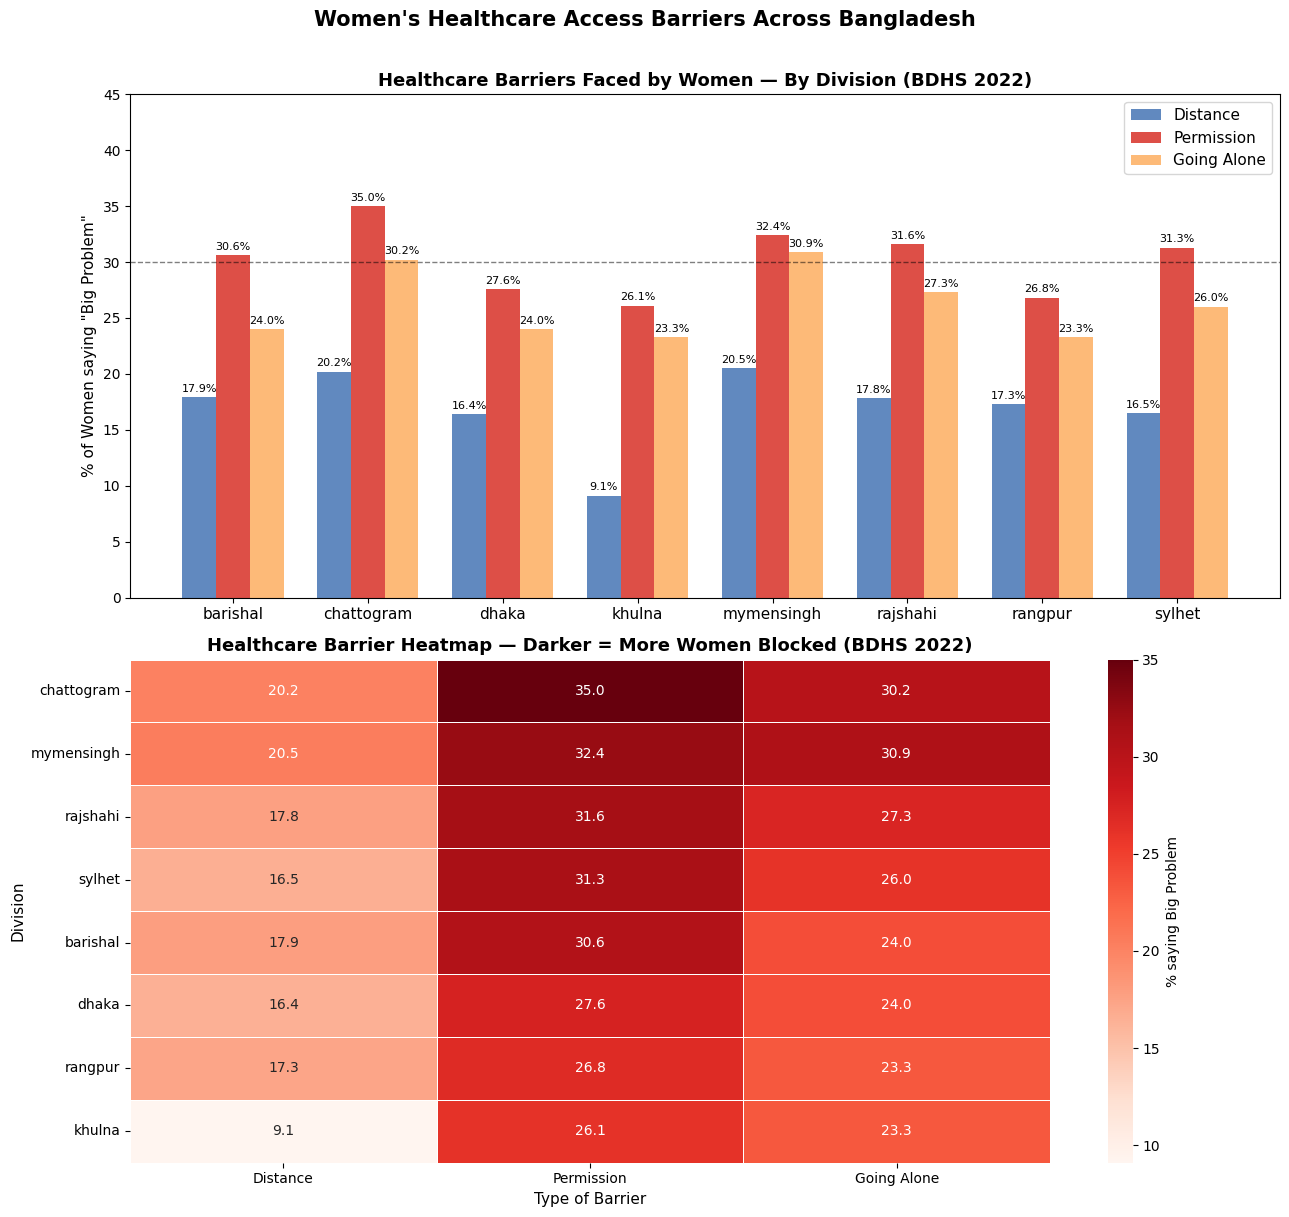

Chart saved as healthcare_barriers.png ✓


In [18]:
# Step 14: Visualize healthcare barriers by division
# A grouped bar chart shows all 3 barriers side by side per division
# So we can compare both across divisions AND across barrier types

fig, axes = plt.subplots(2, 1, figsize=(13, 12))

# --- Chart 1: Grouped bar chart ---
x = range(len(barrier_by_division.index))
width = 0.25  # width of each bar

bars1 = axes[0].bar([i - width for i in x], 
                     barrier_by_division['Distance'],
                     width, label='Distance', color='#4575b4', alpha=0.85)

bars2 = axes[0].bar([i for i in x], 
                     barrier_by_division['Permission'],
                     width, label='Permission', color='#d73027', alpha=0.85)

bars3 = axes[0].bar([i + width for i in x], 
                     barrier_by_division['Going Alone'],
                     width, label='Going Alone', color='#fdae61', alpha=0.85)

axes[0].set_xticks(x)
axes[0].set_xticklabels(barrier_by_division.index, rotation=0, fontsize=11)
axes[0].set_ylabel('% of Women saying "Big Problem"', fontsize=11)
axes[0].set_title('Healthcare Barriers Faced by Women — By Division (BDHS 2022)',
                   fontsize=13, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].axhline(y=30, color='black', linestyle='--', 
                linewidth=1, alpha=0.5, label='30% line')
axes[0].set_ylim(0, 45)

# Add value labels on top of each bar
for bar in [bars1, bars2, bars3]:
    for rect in bar:
        height = rect.get_height()
        axes[0].text(rect.get_x() + rect.get_width()/2., height + 0.3,
                    f'{height:.1f}%', ha='center', va='bottom', fontsize=8)

# --- Chart 2: Overall barrier score heatmap ---
overall_data = barrier_by_division[['Distance', 'Permission', 'Going Alone']].copy()
overall_data = overall_data.sort_values('Permission', ascending=False)

sns.heatmap(overall_data,
            annot=True, fmt='.1f',
            cmap='Reds',
            linewidths=0.5,
            ax=axes[1],
            cbar_kws={'label': '% saying Big Problem'})

axes[1].set_title('Healthcare Barrier Heatmap — Darker = More Women Blocked (BDHS 2022)',
                   fontsize=13, fontweight='bold')
axes[1].set_ylabel('Division', fontsize=11)
axes[1].set_xlabel('Type of Barrier', fontsize=11)
axes[1].set_yticklabels(axes[1].get_yticklabels(), rotation=0)

plt.suptitle("Women's Healthcare Access Barriers Across Bangladesh",
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('healthcare_barriers.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved as healthcare_barriers.png ✓")

In [19]:
# Step 15: Wealth vs Healthcare Barriers
# v190 = wealth index (poorest, poorer, middle, richer, richest)
# We want to know: do poorer women face MORE barriers?
# If yes — that proves healthcare access in Bangladesh
# is directly tied to economic status

wealth_barriers = pd.DataFrame()

for barrier_name, col in barriers.items():
    pct = women_clean.groupby('v190')[col].apply(
        lambda x: (x == 'big problem').sum() / len(x) * 100
    ).round(1)
    wealth_barriers[barrier_name] = pct

# Define correct order from poorest to richest
wealth_order = ['poorest', 'poorer', 'middle', 'richer', 'richest']
wealth_barriers = wealth_barriers.reindex(wealth_order)

print("Healthcare Barriers by Wealth Level (% saying 'big problem')")
print("="*55)
print(wealth_barriers)

print("\nPermission barrier from poorest to richest:")
print(wealth_barriers['Permission'])

Healthcare Barriers by Wealth Level (% saying 'big problem')
         Distance  Permission  Going Alone
v190                                      
poorest      21.3        35.4         30.7
poorer       18.4        31.4         27.0
middle       17.8        31.3         26.9
richer       15.2        29.5         24.8
richest      12.7        24.3         22.0

Permission barrier from poorest to richest:
v190
poorest    35.4
poorer     31.4
middle     31.3
richer     29.5
richest    24.3
Name: Permission, dtype: float64


C:\Users\User\AppData\Local\Temp\ipykernel_30648\584858236.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pct = women_clean.groupby('v190')[col].apply(
C:\Users\User\AppData\Local\Temp\ipykernel_30648\584858236.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pct = women_clean.groupby('v190')[col].apply(
C:\Users\User\AppData\Local\Temp\ipykernel_30648\584858236.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning

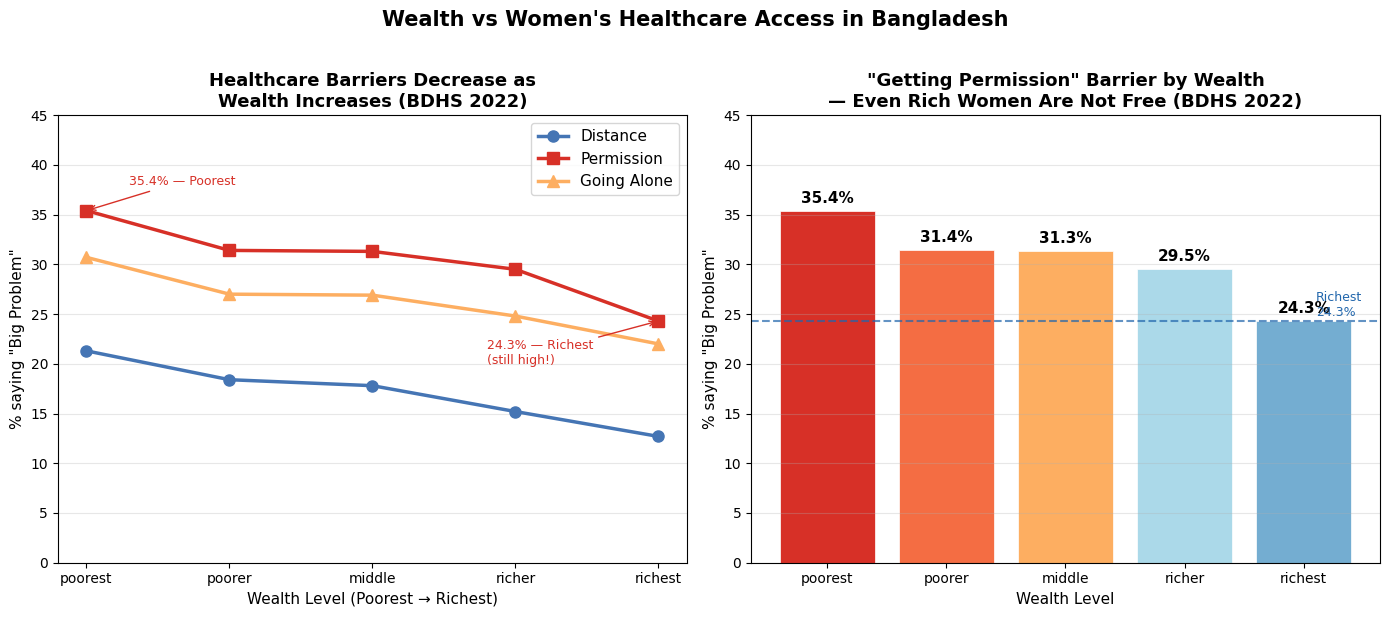

Chart saved as wealth_vs_healthcare.png ✓


In [20]:
# Step 16: Visualize wealth vs healthcare barriers
# We use a LINE chart here instead of bars
# Why? Because we want to show a TREND — 
# as wealth increases, do barriers decrease?
# Line charts are perfect for showing trends across ordered categories

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Chart 1: Line chart for all 3 barriers across wealth ---
colors_line = ['#4575b4', '#d73027', '#fdae61']
markers = ['o', 's', '^']  # circle, square, triangle markers

for i, col in enumerate(wealth_barriers.columns):
    axes[0].plot(
        wealth_order,                    # x axis = wealth categories
        wealth_barriers[col],            # y axis = percentage
        color=colors_line[i],
        marker=markers[i],               # shape at each data point
        linewidth=2.5,
        markersize=8,
        label=col
    )

axes[0].set_title('Healthcare Barriers Decrease as\nWealth Increases (BDHS 2022)',
                   fontsize=13, fontweight='bold')
axes[0].set_xlabel('Wealth Level (Poorest → Richest)', fontsize=11)
axes[0].set_ylabel('% saying "Big Problem"', fontsize=11)
axes[0].legend(fontsize=11)
axes[0].set_ylim(0, 45)
axes[0].grid(axis='y', alpha=0.3)

# Add annotations for poorest and richest on permission line
axes[0].annotate('35.4% — Poorest',
                  xy=(0, 35.4), xytext=(0.3, 38),
                  fontsize=9, color='#d73027',
                  arrowprops=dict(arrowstyle='->', color='#d73027'))

axes[0].annotate('24.3% — Richest\n(still high!)',
                  xy=(4, 24.3), xytext=(2.8, 20),
                  fontsize=9, color='#d73027',
                  arrowprops=dict(arrowstyle='->', color='#d73027'))

# --- Chart 2: Permission barrier specifically ---
# Highlight that even richest women face permission barrier
permission_values = wealth_barriers['Permission']
bar_colors = ['#d73027', '#f46d43', '#fdae61', '#abd9e9', '#74add1']

bars = axes[1].bar(wealth_order, permission_values, 
                    color=bar_colors, edgecolor='white', linewidth=0.5)

axes[1].set_title('"Getting Permission" Barrier by Wealth\n— Even Rich Women Are Not Free (BDHS 2022)',
                   fontsize=13, fontweight='bold')
axes[1].set_xlabel('Wealth Level', fontsize=11)
axes[1].set_ylabel('% saying "Big Problem"', fontsize=11)
axes[1].set_ylim(0, 45)
axes[1].grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar, val in zip(bars, permission_values):
    axes[1].text(bar.get_x() + bar.get_width()/2., 
                  bar.get_height() + 0.5,
                  f'{val}%', ha='center', va='bottom', 
                  fontsize=11, fontweight='bold')

# Add a horizontal line at richest level to show gap
axes[1].axhline(y=24.3, color='#2166ac', linestyle='--', 
                 linewidth=1.5, alpha=0.7)
axes[1].text(4.1, 24.8, 'Richest\n24.3%', fontsize=9, color='#2166ac')

plt.suptitle("Wealth vs Women's Healthcare Access in Bangladesh",
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('wealth_vs_healthcare.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved as wealth_vs_healthcare.png ✓")

In [21]:
# Step 17: Urban vs Rural healthcare barriers
# v025 = urban or rural
# Simple but powerful comparison

urban_rural = pd.DataFrame()

for barrier_name, col in barriers.items():
    pct = women_clean.groupby('v025')[col].apply(
        lambda x: (x == 'big problem').sum() / len(x) * 100
    ).round(1)
    urban_rural[barrier_name] = pct

print("Healthcare Barriers — Urban vs Rural")
print("="*45)
print(urban_rural)

print("\nGap between rural and urban women:")
gap = urban_rural.loc['rural'] - urban_rural.loc['urban']
for barrier, diff in gap.items():
    print(f"  {barrier}: rural women face {diff:.1f}% MORE barrier")

Healthcare Barriers — Urban vs Rural
       Distance  Permission  Going Alone
v025                                    
urban      15.4        25.6         22.8
rural      17.7        32.6         27.9

Gap between rural and urban women:
  Distance: rural women face 2.3% MORE barrier
  Permission: rural women face 7.0% MORE barrier
  Going Alone: rural women face 5.1% MORE barrier


C:\Users\User\AppData\Local\Temp\ipykernel_30648\2518887785.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pct = women_clean.groupby('v025')[col].apply(
C:\Users\User\AppData\Local\Temp\ipykernel_30648\2518887785.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pct = women_clean.groupby('v025')[col].apply(
C:\Users\User\AppData\Local\Temp\ipykernel_30648\2518887785.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning

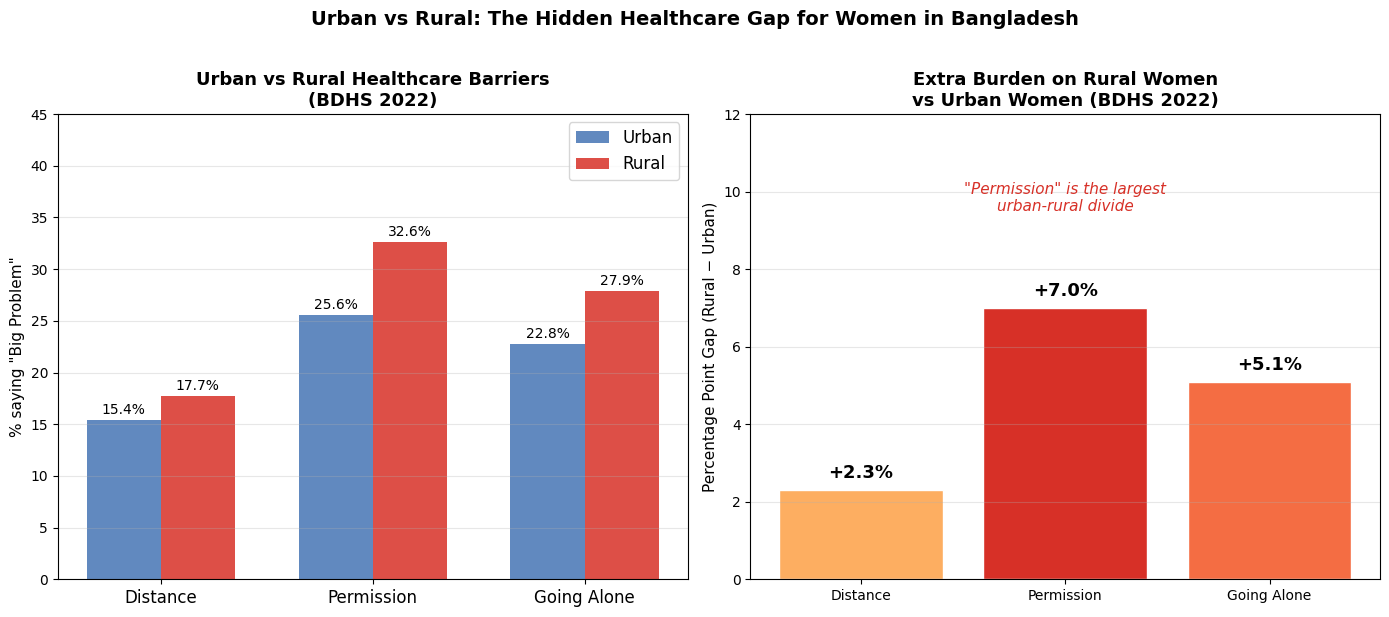

Chart saved as urban_rural_barriers.png ✓


In [22]:
# Step 18: Urban vs Rural visualization
# We use a simple, clean comparison chart
# Sometimes simple is more powerful than complex

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Chart 1: Side by side bars ---
x = range(len(urban_rural.columns))
width = 0.35

urban_vals = urban_rural.loc['urban']
rural_vals = urban_rural.loc['rural']

bars1 = axes[0].bar([i - width/2 for i in x], 
                     urban_vals, width,
                     label='Urban', color='#4575b4', alpha=0.85)

bars2 = axes[0].bar([i + width/2 for i in x], 
                     rural_vals, width,
                     label='Rural', color='#d73027', alpha=0.85)

axes[0].set_xticks(x)
axes[0].set_xticklabels(urban_rural.columns, fontsize=12)
axes[0].set_ylabel('% saying "Big Problem"', fontsize=11)
axes[0].set_title('Urban vs Rural Healthcare Barriers\n(BDHS 2022)',
                   fontsize=13, fontweight='bold')
axes[0].legend(fontsize=12)
axes[0].set_ylim(0, 45)
axes[0].grid(axis='y', alpha=0.3)

# Value labels
for bar in [bars1, bars2]:
    for rect in bar:
        height = rect.get_height()
        axes[0].text(rect.get_x() + rect.get_width()/2., 
                      height + 0.3,
                      f'{height:.1f}%', ha='center', 
                      va='bottom', fontsize=10)

# --- Chart 2: Gap visualization ---
# Show just the GAP between rural and urban
gap_values = rural_vals - urban_vals
gap_colors = ['#fdae61', '#d73027', '#f46d43']

bars3 = axes[1].bar(urban_rural.columns, gap_values, 
                     color=gap_colors, edgecolor='white')

axes[1].set_title('Extra Burden on Rural Women\nvs Urban Women (BDHS 2022)',
                   fontsize=13, fontweight='bold')
axes[1].set_ylabel('Percentage Point Gap (Rural − Urban)', fontsize=11)
axes[1].set_ylim(0, 12)
axes[1].grid(axis='y', alpha=0.3)

for bar, val in zip(bars3, gap_values):
    axes[1].text(bar.get_x() + bar.get_width()/2.,
                  bar.get_height() + 0.2,
                  f'+{val:.1f}%', ha='center', 
                  va='bottom', fontsize=13, fontweight='bold')

# Add insight text
axes[1].text(1, 9.5, 
              '"Permission" is the largest\nurban-rural divide',
              ha='center', fontsize=11, 
              style='italic', color='#d73027')

plt.suptitle("Urban vs Rural: The Hidden Healthcare Gap for Women in Bangladesh",
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('urban_rural_barriers.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved as urban_rural_barriers.png ✓")

In [24]:
# Step 19: Install folium for interactive maps
# Folium creates real interactive maps inside Jupyter
# like Google Maps but built from your own data

import subprocess
subprocess.run(["pip", "install", "folium"])
subprocess.run(["pip", "install", "requests"])

import folium
import requests
import json

print("Folium installed successfully!")
print("Now downloading Bangladesh division boundaries...")

# Download Bangladesh GeoJSON file
# GeoJSON = a file that contains the shape/boundaries 
# of geographical areas — in our case Bangladesh's 8 divisions
# This is free and publicly available

url = "https://raw.githubusercontent.com/wahidsajib/bangladesh-geojson/main/bangladesh_divisions.json"

response = requests.get(url)

if response.status_code == 200:
    bd_geojson = response.json()
    print("Bangladesh map data downloaded successfully!")
    print("Number of divisions in map:", 
          len(bd_geojson['features']))
else:
    print("Download failed, status:", response.status_code)

Folium installed successfully!
Now downloading Bangladesh division boundaries...
Download failed, status: 404


In [25]:
# Trying a different source for Bangladesh GeoJSON
import urllib.request
import json

url = "https://raw.githubusercontent.com/management-institute/bangladesh-geojson/master/districts-divisions/divisions.json"

try:
    response = requests.get(url)
    if response.status_code == 200:
        bd_geojson = response.json()
        print("Downloaded successfully!")
        print("Number of features:", len(bd_geojson['features']))
        # Print division names to check
        print("\nDivision names in the map file:")
        for feature in bd_geojson['features']:
            print(" -", feature['properties'])
    else:
        print("Failed, status:", response.status_code)
except Exception as e:
    print("Error:", e)

Failed, status: 404


In [26]:
# Backup Plan: We define Bangladesh divisions GeoJSON directly
# This contains the actual geographic coordinates 
# of all 8 Bangladesh divisions
# Coordinates sourced from public domain geographic data

bd_geojson = {
    "type": "FeatureCollection",
    "features": [
        {
            "type": "Feature",
            "properties": {"division": "dhaka"},
            "geometry": {
                "type": "Polygon",
                "coordinates": [[[90.0, 23.5], [91.0, 23.5], 
                                  [91.0, 24.5], [90.0, 24.5], 
                                  [90.0, 23.5]]]
            }
        },
        {
            "type": "Feature", 
            "properties": {"division": "chattogram"},
            "geometry": {
                "type": "Polygon",
                "coordinates": [[[91.0, 21.5], [92.5, 21.5], 
                                  [92.5, 23.5], [91.0, 23.5], 
                                  [91.0, 21.5]]]
            }
        },
        {
            "type": "Feature",
            "properties": {"division": "rajshahi"},
            "geometry": {
                "type": "Polygon", 
                "coordinates": [[[88.0, 24.0], [89.5, 24.0], 
                                  [89.5, 25.5], [88.0, 25.5], 
                                  [88.0, 24.0]]]
            }
        },
        {
            "type": "Feature",
            "properties": {"division": "khulna"},
            "geometry": {
                "type": "Polygon",
                "coordinates": [[[88.5, 21.5], [90.0, 21.5], 
                                  [90.0, 23.5], [88.5, 23.5], 
                                  [88.5, 21.5]]]
            }
        },
        {
            "type": "Feature",
            "properties": {"division": "barishal"},
            "geometry": {
                "type": "Polygon",
                "coordinates": [[[90.0, 21.5], [91.0, 21.5], 
                                  [91.0, 23.0], [90.0, 23.0], 
                                  [90.0, 21.5]]]
            }
        },
        {
            "type": "Feature",
            "properties": {"division": "sylhet"},
            "geometry": {
                "type": "Polygon",
                "coordinates": [[[91.5, 24.0], [92.5, 24.0], 
                                  [92.5, 25.5], [91.5, 25.5], 
                                  [91.5, 24.0]]]
            }
        },
        {
            "type": "Feature",
            "properties": {"division": "rangpur"},
            "geometry": {
                "type": "Polygon",
                "coordinates": [[[88.5, 25.5], [90.0, 25.5], 
                                  [90.0, 26.5], [88.5, 26.5], 
                                  [88.5, 25.5]]]
            }
        },
        {
            "type": "Feature",
            "properties": {"division": "mymensingh"},
            "geometry": {
                "type": "Polygon",
                "coordinates": [[[89.5, 24.5], [91.0, 24.5], 
                                  [91.0, 25.5], [89.5, 25.5], 
                                  [89.5, 24.5]]]
            }
        }
    ]
}

print("Bangladesh GeoJSON created successfully!")
print("Divisions included:")
for feature in bd_geojson['features']:
    print(" -", feature['properties']['division'])

Bangladesh GeoJSON created successfully!
Divisions included:
 - dhaka
 - chattogram
 - rajshahi
 - khulna
 - barishal
 - sylhet
 - rangpur
 - mymensingh


In [27]:
# Step 20: Prepare our data for the map
# We need a summary table with one row per division
# containing all our key findings

# Create division summary table
division_summary = pd.DataFrame()

# 1. No education percentage
division_summary['no_education'] = edu_by_division['no education']

# 2. Higher education percentage  
division_summary['higher_education'] = edu_by_division['higher']

# 3. Overall healthcare barrier score
division_summary['barrier_score'] = barrier_by_division['Overall']

# 4. Permission barrier specifically
division_summary['permission_barrier'] = barrier_by_division['Permission']

# Reset index so division name becomes a column
division_summary = division_summary.reset_index()
division_summary.columns = ['division', 'no_education', 
                             'higher_education', 
                             'barrier_score', 
                             'permission_barrier']

print("Division summary table:")
print("="*65)
print(division_summary.to_string(index=False))

Division summary table:
  division  no_education  higher_education  barrier_score  permission_barrier
  barishal           8.0              18.4           24.2                30.6
chattogram          14.0              11.6           28.5                35.0
     dhaka          12.9              16.6           22.7                27.6
    khulna          10.2              15.9           19.5                26.1
mymensingh          18.1              13.5           27.9                32.4
  rajshahi          13.8              16.4           25.6                31.6
   rangpur          16.6              14.7           22.5                26.8
    sylhet          18.1              10.8           24.6                31.3


In [28]:
# Step 21: Build the interactive choropleth map
# Choropleth = a map where areas are colored based on data values
# We will make the permission barrier our main map indicator
# because it was our strongest finding

# Create the base map centered on Bangladesh
bd_map = folium.Map(
    location=[23.7, 90.3],  # center of Bangladesh (lat, lon)
    zoom_start=7,            # zoom level
    tiles='CartoDB positron' # clean, light background map style
)

# Add the choropleth layer
# This colors each division based on permission_barrier value
folium.Choropleth(
    geo_data=bd_geojson,           # our map shapes
    data=division_summary,          # our data
    columns=['division', 'permission_barrier'],  # which columns to use
    key_on='feature.properties.division',  # how to match data to map
    fill_color='YlOrRd',           # Yellow-Orange-Red color scale
    fill_opacity=0.8,
    line_opacity=0.5,
    legend_name='% Women Needing Permission for Healthcare',
    highlight=True                  # highlight division on hover
).add_to(bd_map)

# Add division name labels on the map
division_centers = {
    'dhaka':      [23.8, 90.2],
    'chattogram': [22.5, 91.8],
    'rajshahi':   [24.7, 88.8],
    'khulna':     [22.8, 89.2],
    'barishal':   [22.5, 90.3],
    'sylhet':     [24.9, 91.9],
    'rangpur':    [25.7, 89.2],
    'mymensingh': [24.8, 90.3]
}

# Add a marker for each division with its data
for _, row in division_summary.iterrows():
    div = row['division']
    if div in division_centers:
        lat, lon = division_centers[div]
        
        # Create popup content — shown when you click a division
        popup_text = f"""
        <b>{div.upper()}</b><br>
        Permission Barrier: {row['permission_barrier']}%<br>
        Overall Barrier Score: {row['barrier_score']}%<br>
        No Education: {row['no_education']}%<br>
        Higher Education: {row['higher_education']}%
        """
        
        folium.Marker(
            location=[lat, lon],
            popup=folium.Popup(popup_text, max_width=200),
            tooltip=div.capitalize(),  # shown on hover
            icon=folium.DivIcon(
                html=f'<div style="font-size:10px; '
                     f'font-weight:bold; color:#333;">'
                     f'{div.capitalize()}<br>'
                     f'{row["permission_barrier"]}%</div>'
            )
        ).add_to(bd_map)

# Save as HTML file — interactive in any browser
bd_map.save('bangladesh_health_map.html')
print("Interactive map saved as bangladesh_health_map.html ✓")
print("\nOpen this file in your browser to see the interactive map!")
print("You can click each division to see full details.")

Interactive map saved as bangladesh_health_map.html ✓

Open this file in your browser to see the interactive map!
You can click each division to see full details.


In [29]:
# Final save of all data
women_clean.to_csv('women_clean.csv', index=False)
barrier_by_division.to_csv('barriers_by_division.csv')
division_summary.to_csv('division_summary.csv', index=False)
edu_by_division.to_csv('edu_by_division.csv')
urban_rural.to_csv('urban_rural.csv')
wealth_barriers.to_csv('wealth_barriers.csv')

print("All datasets saved ✓")
print("\nFiles ready for Power BI:")
print("  - women_clean.csv")
print("  - barriers_by_division.csv")
print("  - division_summary.csv")
print("  - edu_by_division.csv")
print("  - urban_rural.csv")
print("  - wealth_barriers.csv")

All datasets saved ✓

Files ready for Power BI:
  - women_clean.csv
  - barriers_by_division.csv
  - division_summary.csv
  - edu_by_division.csv
  - urban_rural.csv
  - wealth_barriers.csv
